# 01 — Exploración de datos

**Proyecto:** Distribución de pares de Cooper  
**Materiales:** Al, Nb, Ta, Pb y Hg

Este notebook inspecciona automáticamente los tres materiales que cuentan con los tres archivos necesarios: \(\alpha^2F(\omega)\), DOS fonónica y DOS electrónica. La estructura y unidades de los CSV se consideran comunes para los tres materiales.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks": ROOT = ROOT.parent
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))

from src.io import read_eliashberg, read_phonon_dos, read_electronic_dos
from src.preprocessing import preprocess_eliashberg, preprocess_phonon_dos, preprocess_electronic_dos
from src.plotting import plot_eliashberg, plot_phonon_dos, plot_electronic_dos

MATERIALES = ["Al", "Nb", "Ta", "Pb", "Hg"]
RAW_DIR = ROOT / "data" / "raw"
FIG_DIR = ROOT / "results" / "figures"
print("Materiales:", MATERIALES)

Materiales: ['Al', 'Nb', 'Ta', 'Pb', 'Hg']


## 1. Estructura de archivos

Para cada material se esperan exactamente estos nombres:

```text
{material}_alpha2F.csv
{material}_DOS_fonones.csv
{material}_DOS_electronica.csv
```

Las energías de los nuevos CSV se manejan en meV y la energía electrónica es relativa a \(E_F\).

In [2]:
required = ["alpha2F", "DOS_fonones", "DOS_electronica"]
status=[]
for mat in MATERIALES:
    folder=RAW_DIR/mat
    paths=[folder/f"{mat}_alpha2F.csv", folder/f"{mat}_DOS_fonones.csv", folder/f"{mat}_DOS_electronica.csv"]
    row={"material":mat}
    for key,p in zip(required,paths): row[key] = p.exists()
    status.append(row)
status_df=pd.DataFrame(status)
display(status_df)
if not status_df[required].all().all(): raise FileNotFoundError("Faltan uno o más CSV.")

,material,alpha2F,DOS_fonones,DOS_electronica
0,Al,True,True,True
1,Nb,True,True,True
2,Ta,True,True,True
3,Pb,True,True,True
4,Hg,True,True,True


## 2. Inspección de columnas y tamaño

In [3]:
for mat in MATERIALES:
    folder=RAW_DIR/mat
    print(f"\n===== {mat} =====")
    for p in [folder/f"{mat}_alpha2F.csv",folder/f"{mat}_DOS_fonones.csv",folder/f"{mat}_DOS_electronica.csv"]:
        df=pd.read_csv(p)
        print(f"{p.name}: {df.shape}, columnas={list(df.columns)}")
        print(df.head(2))


===== Al =====
Al_alpha2F.csv: (400, 3), columnas=['frecuencia_THz', 'energia_meV', 'alpha2F']
   frecuencia_THz  energia_meV       alpha2F
0        0.012007     0.049656  1.263495e-09
1        0.036021     0.148971  3.403759e-08
Al_DOS_fonones.csv: (400, 3), columnas=['frecuencia_THz', 'energia_meV', 'DOS_fonones']
   frecuencia_THz   energia_meV   DOS_fonones
0   -4.987284e-08 -2.062575e-07  0.000000e+00
1    2.401418e-02  9.931467e-02  6.593980e-08
Al_DOS_electronica.csv: (644, 3), columnas=['E_minus_EF_eV', 'energia_meV', 'DOS_electronica']
   E_minus_EF_eV  energia_meV  DOS_electronica
0        -11.972     -11972.0        -0.000002
1        -11.922     -11922.0        -0.000006

===== Nb =====
Nb_alpha2F.csv: (400, 3), columnas=['frecuencia_THz', 'energia_meV', 'alpha2F']
   frecuencia_THz  energia_meV       alpha2F
0        0.007943     0.032851  7.747585e-08
1        0.023830     0.098554  2.101771e-06
Nb_DOS_fonones.csv: (400, 3), columnas=['frecuencia_THz', 'energia_meV', 'DO

## 3. Carga y preprocesamiento

In [4]:
processed = {}

for mat in MATERIALES:
    folder = RAW_DIR / mat

    a = read_eliashberg(folder / f"{mat}_alpha2F.csv")
    ph = read_phonon_dos(folder / f"{mat}_DOS_fonones.csv")
    el = read_electronic_dos(folder / f"{mat}_DOS_electronica.csv")

    try:
        eli = preprocess_eliashberg(
            a["frequency_mev"],
            a["a2f_total"],
        )
        omega_c = float(eli["omega_c_mev"])

    except ValueError as err:
        if "No se encontró un punto con alpha^2F = 0" not in str(err):
            raise

        freq = np.asarray(a["frequency_mev"], dtype=float)
        a2f = np.asarray(a["a2f_total"], dtype=float)

        m = (
            np.isfinite(freq)
            & np.isfinite(a2f)
            & (freq >= 0.0)
            & (a2f >= 0.0)
        )

        freq = freq[m]
        a2f = a2f[m]

        if freq.size == 0:
            raise ValueError(f"{mat}: sin datos válidos de Eliashberg.")

        order = np.argsort(freq)
        freq = freq[order]
        a2f = a2f[order]

        omega_c = float(freq[-1])

        eli = {
            "frequency_mev": freq,
            "a2f_total": a2f,
            "omega_c_mev": omega_c,
        }

    p = preprocess_phonon_dos(
        ph["frequency_mev"],
        ph["dos"],
        omega_c_mev=omega_c,
    )

    # cutoff electrónico robusto
    eps_raw = np.asarray(el["epsilon_mev"], dtype=float)
    dos_raw = np.asarray(el["dos"], dtype=float)

    m_el = np.isfinite(eps_raw) & np.isfinite(dos_raw)
    eps_raw = eps_raw[m_el]
    dos_raw = dos_raw[m_el]

    if eps_raw.size == 0:
        raise ValueError(f"{mat}: epsilon_mev vacío o inválido.")

    abs_eps = np.abs(eps_raw)
    pos_abs_eps = abs_eps[abs_eps > 0.0]

    if pos_abs_eps.size == 0:
        raise ValueError(f"{mat}: epsilon_mev solo contiene 0.")

    omega_c_el_max = float(np.max(abs_eps))
    omega_c_el_min = float(np.min(pos_abs_eps))

    omega_c_el = float(min(omega_c, omega_c_el_max))
    if omega_c_el < omega_c_el_min:
        omega_c_el = omega_c_el_min

    e = preprocess_electronic_dos(
        eps_raw,
        dos_raw,
        omega_c_mev=omega_c_el,
    )

    processed[mat] = {
        "eli": eli,
        "ph": p,
        "el": e,
        "omega_c": omega_c,
        "omega_c_el": omega_c_el,
    }

    print(
        f"{mat}: omega_c={omega_c:.6f} meV "
        f"(elec={omega_c_el:.6f} meV) | "
        f"electron range=[{e['epsilon_mev'].min():.3f}, {e['epsilon_mev'].max():.3f}] meV"
    )

Al: omega_c=39.676242 meV (elec=39.676242 meV) | electron range=[-11972.000, 20178.000] meV
Nb: omega_c=26.248375 meV (elec=26.248375 meV) | electron range=[-55174.000, 17176.000] meV
Ta: omega_c=20.639428 meV (elec=20.639428 meV) | electron range=[-10362.000, 9638.000] meV
Pb: omega_c=9.870604 meV (elec=13.000000 meV) | electron range=[-18087.000, 19913.000] meV
Hg: omega_c=11.342195 meV (elec=11.342195 meV) | electron range=[-28924.000, 11076.000] meV


## 4. Resumen de parámetros

In [5]:
summary=[]
for mat,d in processed.items():
    summary.append({"material":mat,"omega_c_meV":d["omega_c"],"N_alpha2F":len(d["eli"]["frequency_mev"]),"N_phonon":len(d["ph"]["frequency_mev"]),"N_electron":len(d["el"]["epsilon_mev"])})
summary_df=pd.DataFrame(summary)
display(summary_df)

,material,omega_c_meV,N_alpha2F,N_phonon,N_electron
0,Al,39.676242,401,400,644
1,Nb,26.248375,400,400,1448
2,Ta,20.639428,401,400,4001
3,Pb,9.870604,400,400,761
4,Hg,11.342195,400,400,2001


## 5. Gráficas de entrada

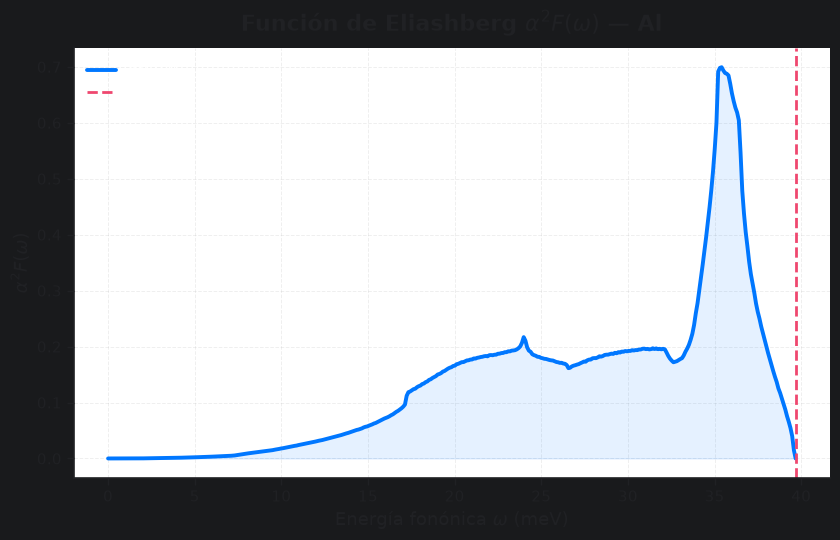

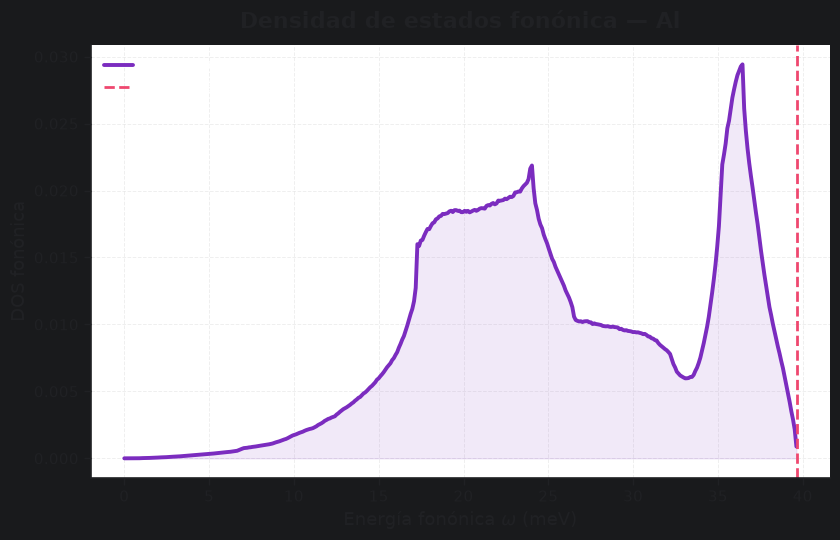

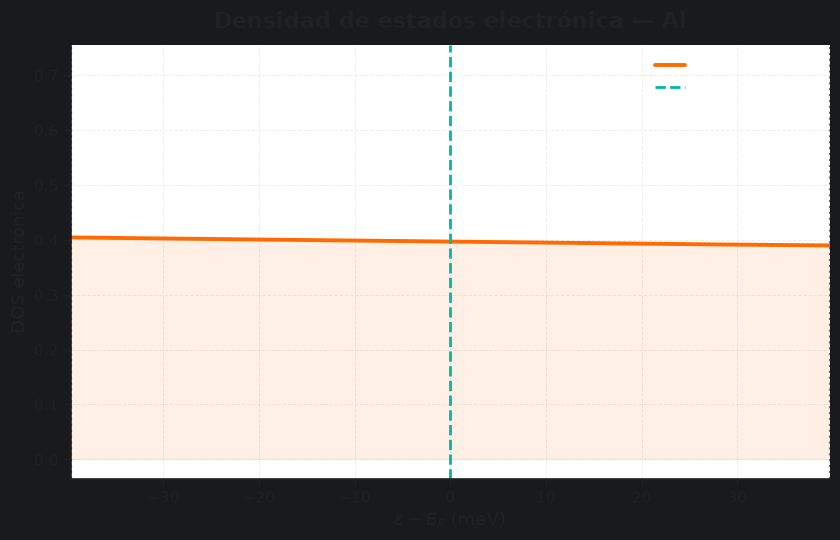

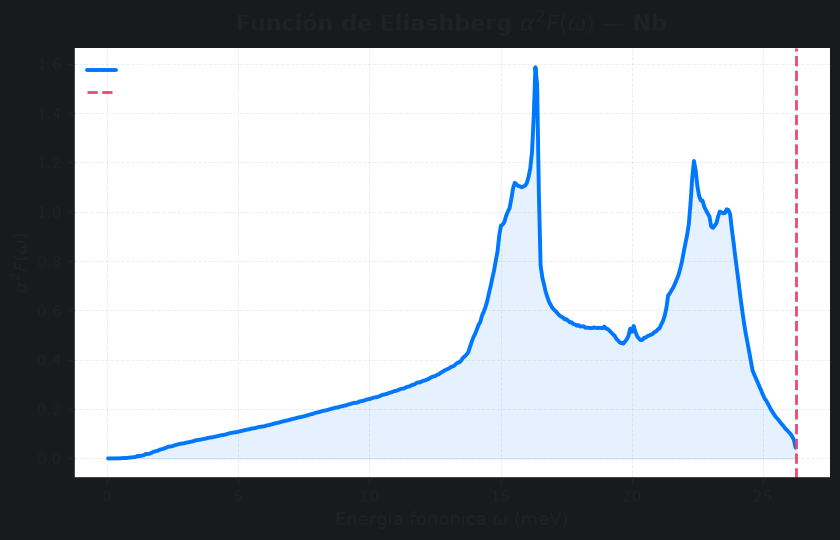

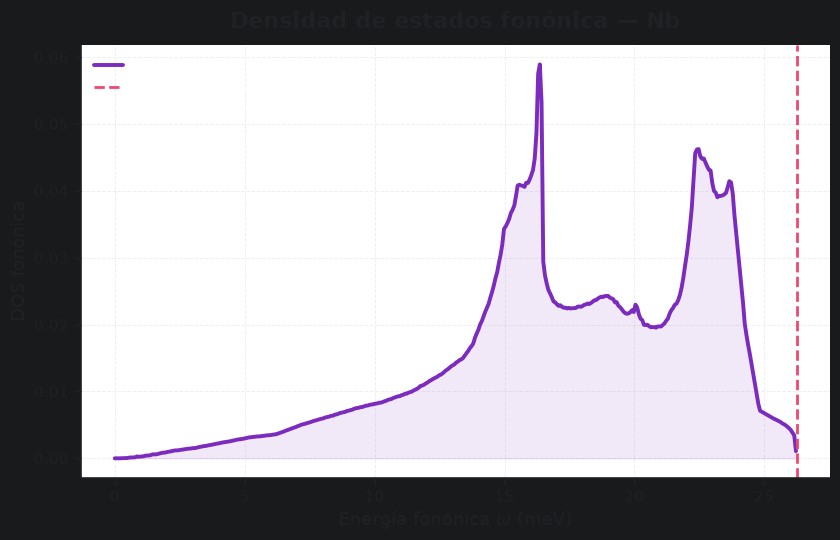

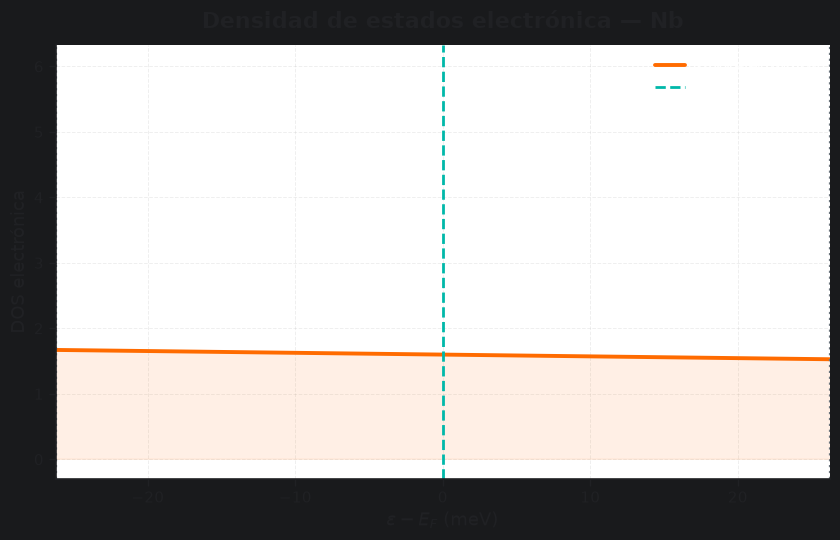

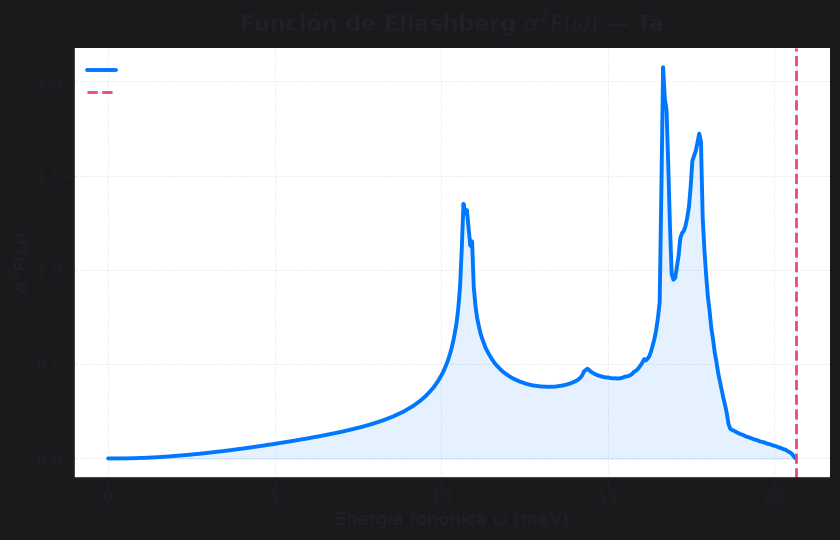

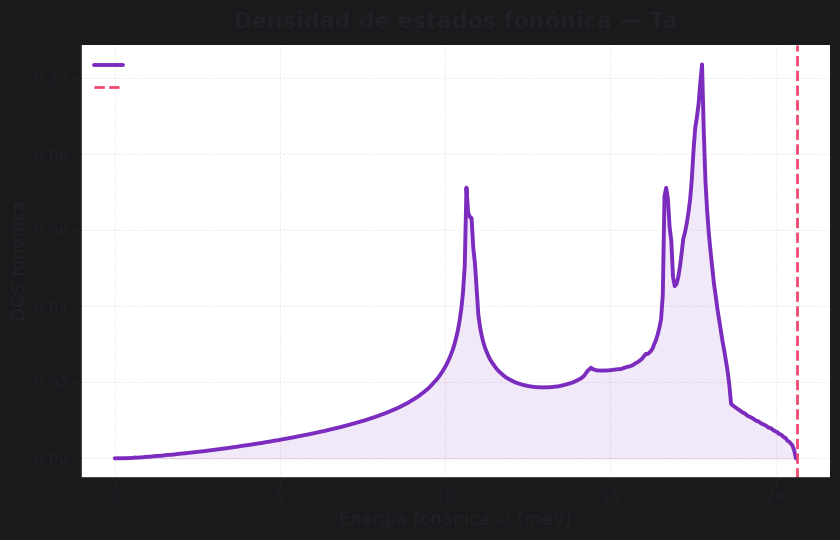

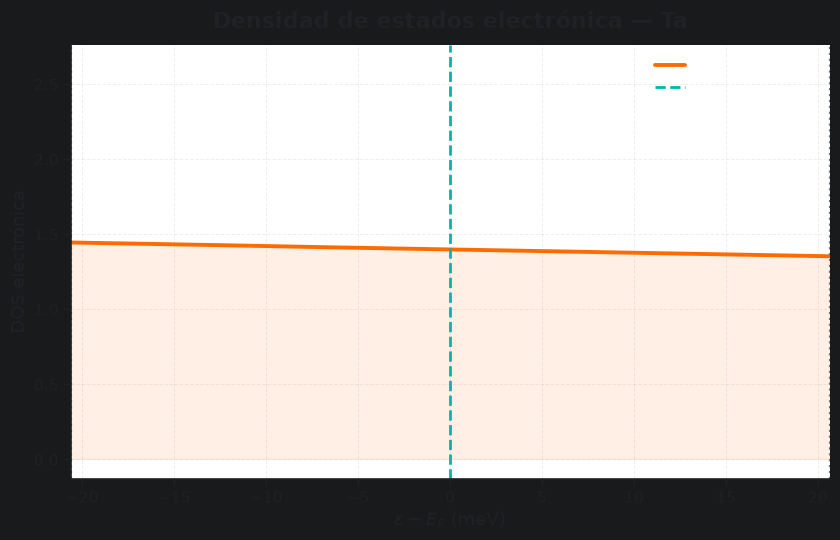

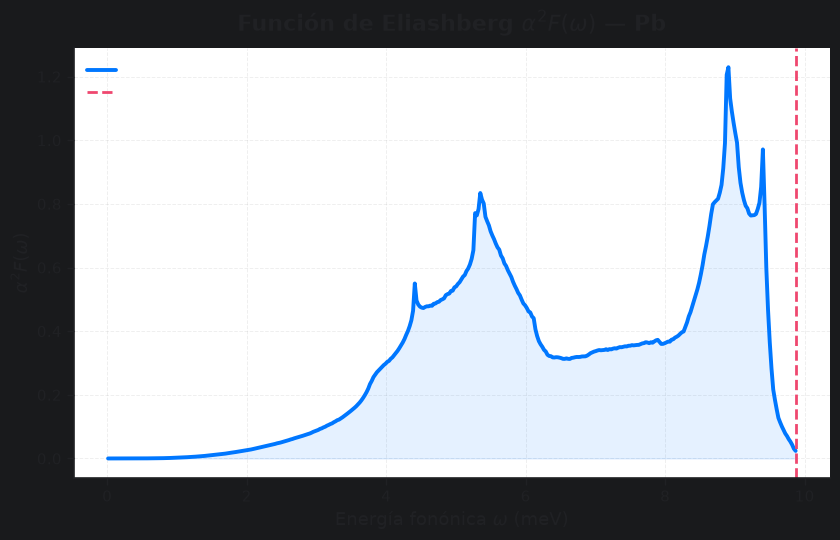

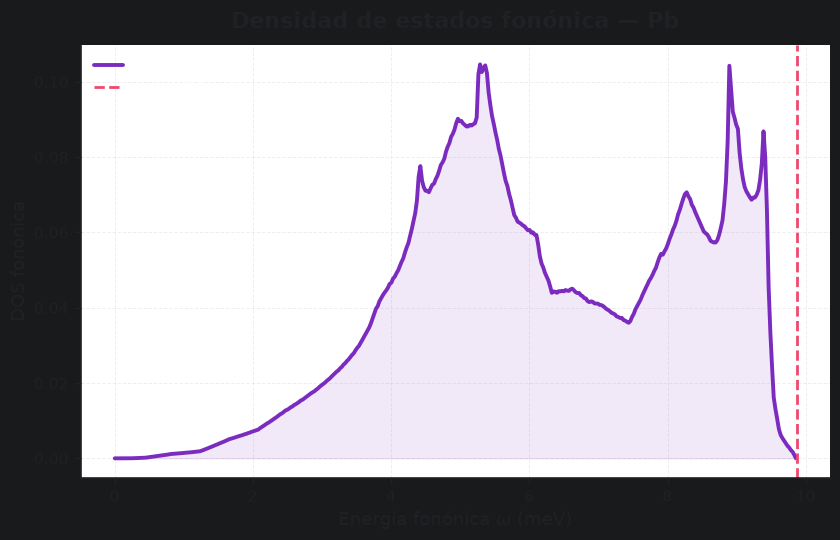

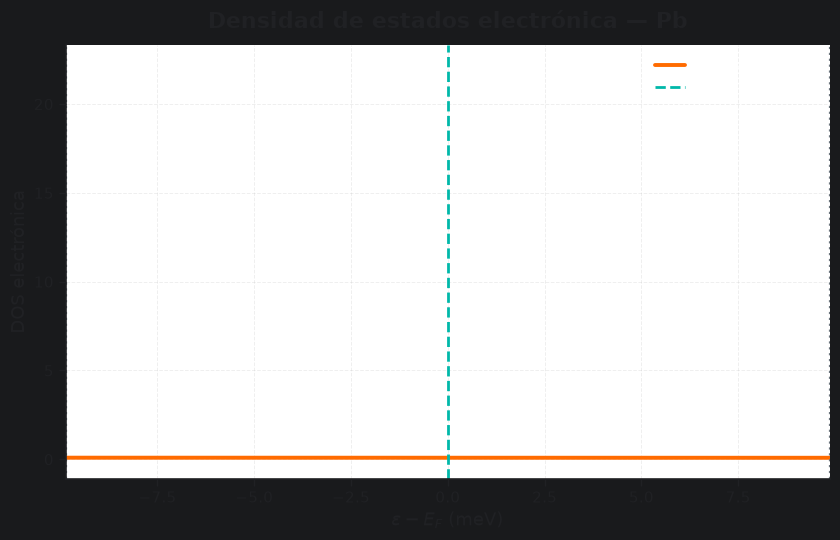

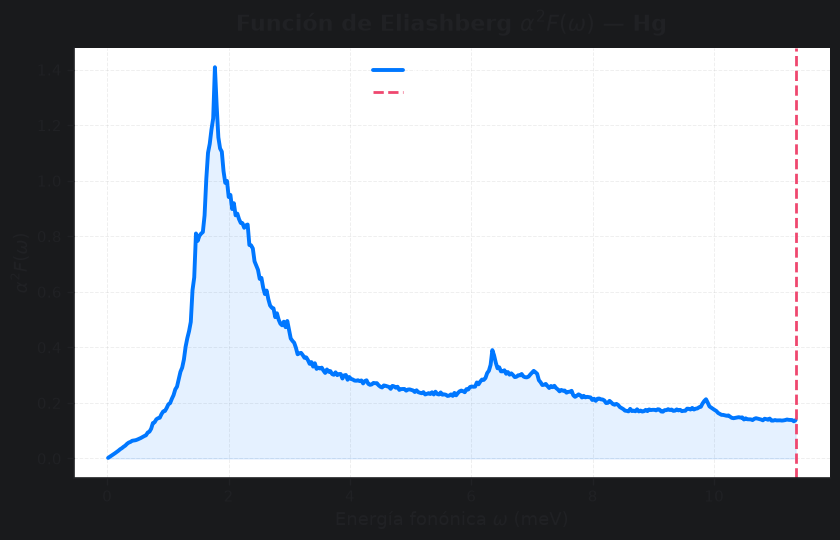

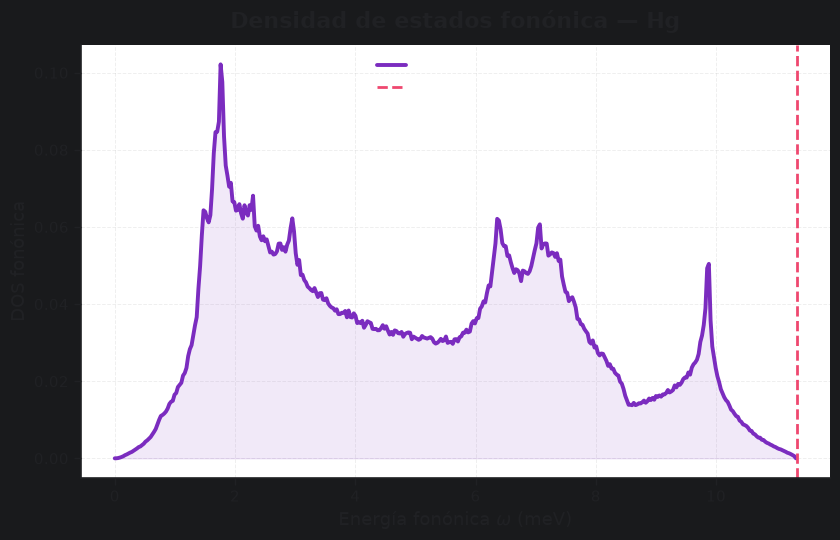

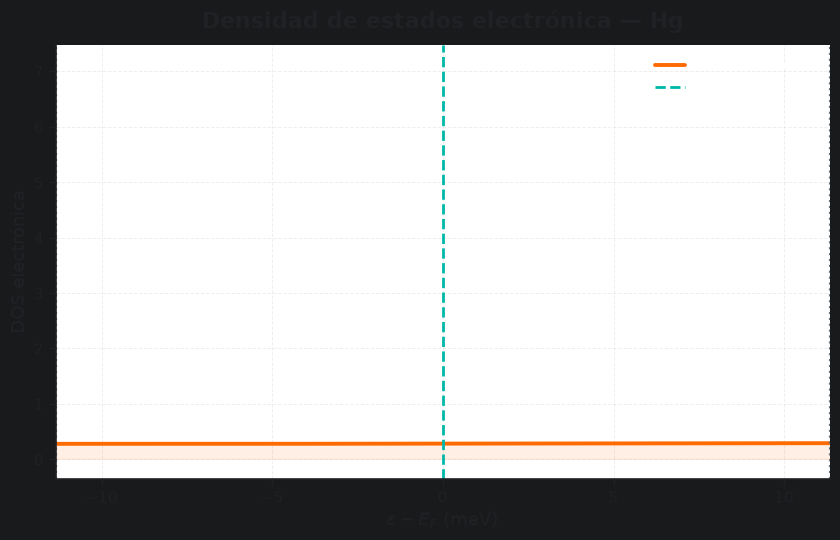

In [6]:
for mat,d in processed.items():
    fig,_=plot_eliashberg(d["eli"]["frequency_mev"],d["eli"]["a2f_total"],d["omega_c"],material=mat); plt.show()
    fig,_=plot_phonon_dos(d["ph"]["frequency_mev"],d["ph"]["dos"],d["omega_c"],material=mat); plt.show()
    fig,_=plot_electronic_dos(d["el"]["epsilon_mev"],d["el"]["dos"],d["omega_c"],material=mat); plt.show()

## Conclusión

Los tres materiales quedan validados bajo la misma convención de datos. Por tanto, los notebooks 02 y 03 pueden aplicar exactamente el mismo procedimiento matemático a **Al, Nb y Pb**, cambiando únicamente los datos y \(T_c\).